# MSCS 634 Lab 4: Regression Analysis and Regularization

**Name:** Bikram Lamsal  
**Course Title:** MSCS 634 - Advanced Big Data and Data Mining  
**Lab Assignment Title:** Lab 4 - Regression Analysis and Regularization Using the Diabetes Dataset

## Step 1: Data Preparation

This section loads the Diabetes dataset from `sklearn.datasets`, explores the feature and target distributions, checks for missing values, and prepares a consistent train-test split for model comparison.

In [1]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")

Matplotlib is building the font cache; this may take a moment.


In [2]:
diabetes = load_diabetes()

X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target, name="disease_progression")

diabetes_df = X.copy()
diabetes_df["disease_progression"] = y

print(f"Dataset shape: {X.shape[0]} rows and {X.shape[1]} features")
print("Feature names:", list(diabetes.feature_names))
diabetes_df.head()

Dataset shape: 442 rows and 10 features
Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,disease_progression
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:
missing_values = diabetes_df.isna().sum().reset_index()
missing_values.columns = ["column", "missing_count"]
missing_values

,column,missing_count
0,age,0
1,sex,0
2,bmi,0
3,bp,0
4,s1,0
5,s2,0
6,s3,0
7,s4,0
8,s5,0
9,s6,0


In [4]:
feature_summary = X.describe().T[["mean", "std", "min", "max"]]
feature_summary

,mean,std,min,max
age,-2.511817e-19,0.047619,-0.107226,0.110727
sex,1.230790e-17,0.047619,-0.044642,0.050680
bmi,-2.245564e-16,0.047619,-0.090275,0.170555
bp,-4.797570e-17,0.047619,-0.112399,0.132044
s1,-1.381499e-17,0.047619,-0.126781,0.153914
s2,3.918434e-17,0.047619,-0.115613,0.198788
s3,-5.777179e-18,0.047619,-0.102307,0.181179
s4,-9.042540e-18,0.047619,-0.076395,0.185234
s5,9.293722e-17,0.047619,-0.126097,0.133597
s6,1.130318e-17,0.047619,-0.137767,0.135612


In [5]:
target_summary = y.describe().to_frame().T
target_summary

,count,mean,std,min,25%,50%,75%,max
disease_progression,442.0,152.133484,77.093005,25.0,87.0,140.5,211.5,346.0


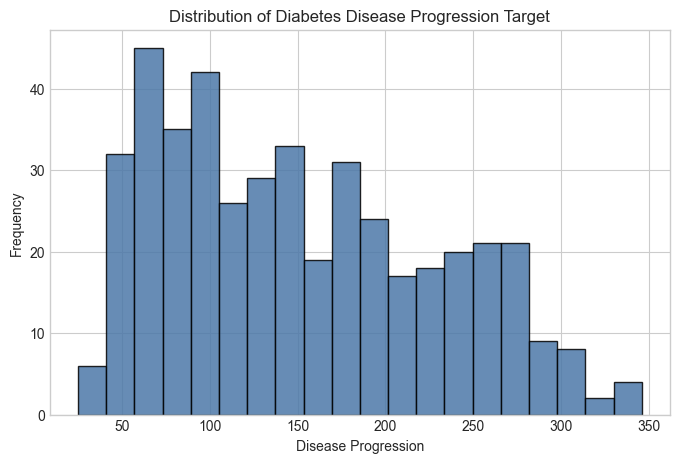

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(y, bins=20, color="#4C78A8", edgecolor="black", alpha=0.85)
ax.set_title("Distribution of Diabetes Disease Progression Target")
ax.set_xlabel("Disease Progression")
ax.set_ylabel("Frequency")
plt.show()

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Testing set: {X_test.shape[0]} rows")

Training set: 353 rows
Testing set: 89 rows


### Data Preparation Interpretation

The Diabetes dataset has 442 observations, 10 numeric health-related features, and a continuous disease-progression target. The target represents a quantitative measure of disease progression, so this is a regression problem rather than a classification problem. There are no missing values, so no imputation or row removal is required.

The features from `sklearn` are already centered and scaled, but `StandardScaler` is still used inside model pipelines for consistency, especially for Ridge and Lasso regularization. This keeps all models on a comparable feature scale and prevents coefficient penalties from being influenced by feature magnitude rather than feature importance.

## Step 2: Simple Linear Regression

A Simple Linear Regression model is trained using only the `bmi` feature to predict disease progression. BMI is a reasonable single-feature choice because it is commonly associated with diabetes progression and gives an interpretable baseline model.

In [8]:
def evaluate_regression(model_name, y_train_actual, y_train_pred, y_test_actual, y_test_pred):
    return {
        "model": model_name,
        "train_rmse": np.sqrt(mean_squared_error(y_train_actual, y_train_pred)),
        "test_mae": mean_absolute_error(y_test_actual, y_test_pred),
        "test_mse": mean_squared_error(y_test_actual, y_test_pred),
        "test_rmse": np.sqrt(mean_squared_error(y_test_actual, y_test_pred)),
        "test_r2": r2_score(y_test_actual, y_test_pred),
    }


simple_feature = "bmi"
simple_model = LinearRegression()
simple_model.fit(X_train[[simple_feature]], y_train)

simple_train_pred = simple_model.predict(X_train[[simple_feature]])
simple_test_pred = simple_model.predict(X_test[[simple_feature]])

simple_metrics = pd.DataFrame([
    evaluate_regression(
        "Simple Linear Regression (BMI)",
        y_train,
        simple_train_pred,
        y_test,
        simple_test_pred
    )
])
simple_metrics

,model,train_rmse,test_mae,test_mse,test_rmse,test_r2
0,Simple Linear Regression (BMI),62.0815,52.259976,4061.825928,63.732456,0.23335


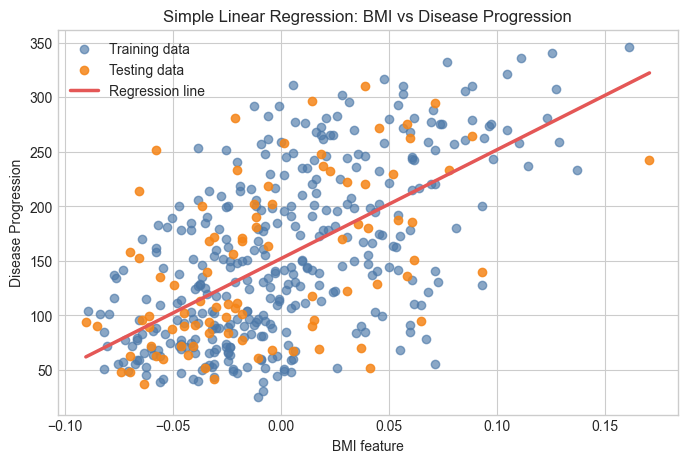

In [9]:
x_line = np.linspace(X[simple_feature].min(), X[simple_feature].max(), 100).reshape(-1, 1)
y_line = simple_model.predict(pd.DataFrame(x_line, columns=[simple_feature]))

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_train[simple_feature], y_train, alpha=0.65, label="Training data", color="#4C78A8")
ax.scatter(X_test[simple_feature], y_test, alpha=0.85, label="Testing data", color="#F58518")
ax.plot(x_line, y_line, color="#E45756", linewidth=2.5, label="Regression line")
ax.set_title("Simple Linear Regression: BMI vs Disease Progression")
ax.set_xlabel("BMI feature")
ax.set_ylabel("Disease Progression")
ax.legend()
plt.show()

### Simple Linear Regression Interpretation

The BMI-only model provides a useful baseline because it tests how much predictive value can be gained from one interpretable feature. The positive slope in the plot suggests that higher BMI values tend to be associated with higher disease progression values. However, the points are widely spread around the regression line, which means BMI alone does not explain much of the variation in the target.

The test R-squared is lower than the multivariable models, and the RMSE is higher. This shows that diabetes progression cannot be modeled well with only one independent variable. The simple model is useful for comparison, but it underfits the broader structure of the dataset.

## Step 3: Multiple Regression

A Multiple Linear Regression model is trained using all 10 independent variables. This model tests whether combining multiple health measurements improves predictive performance compared with the single-feature model.

In [10]:
multiple_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])
multiple_model.fit(X_train, y_train)

multiple_train_pred = multiple_model.predict(X_train)
multiple_test_pred = multiple_model.predict(X_test)

multiple_metrics = pd.DataFrame([
    evaluate_regression(
        "Multiple Linear Regression",
        y_train,
        multiple_train_pred,
        y_test,
        multiple_test_pred
    )
])
multiple_metrics

,model,train_rmse,test_mae,test_mse,test_rmse,test_r2
0,Multiple Linear Regression,53.558843,42.794095,2900.193628,53.853446,0.452603


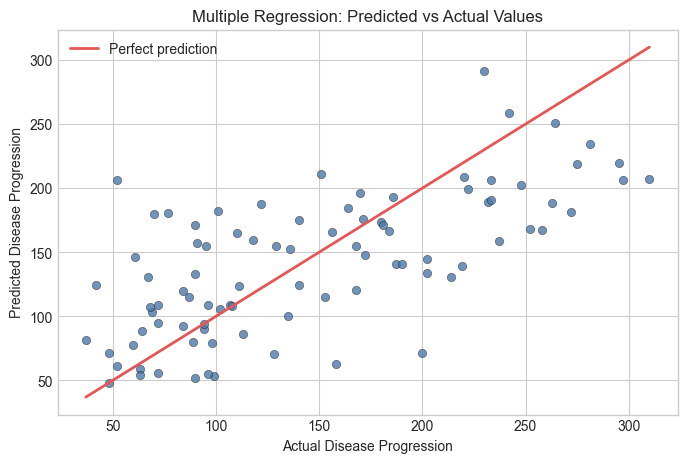

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_test, multiple_test_pred, alpha=0.80, color="#4C78A8", edgecolor="black", linewidth=0.3)
min_value = min(y_test.min(), multiple_test_pred.min())
max_value = max(y_test.max(), multiple_test_pred.max())
ax.plot([min_value, max_value], [min_value, max_value], color="#E45756", linewidth=2, label="Perfect prediction")
ax.set_title("Multiple Regression: Predicted vs Actual Values")
ax.set_xlabel("Actual Disease Progression")
ax.set_ylabel("Predicted Disease Progression")
ax.legend()
plt.show()

### Multiple Regression Interpretation

Using all available features improves performance over the simple BMI-only model. The lower RMSE and higher R-squared indicate that the combined health measurements explain more variation in disease progression than BMI alone. This is expected because diabetes progression is likely influenced by multiple health indicators rather than a single measurement.

The predicted-versus-actual plot shows a clearer trend around the perfect-prediction line, although the model still makes noticeable errors for some high and low target values. This suggests the model captures an important linear signal, but the relationship between the available features and disease progression is not perfectly linear or complete.

## Step 4: Polynomial Regression

Polynomial Regression expands the input features with higher-order terms. Degrees 1 through 4 are compared to show how model complexity can move from underfitting toward overfitting.

In [12]:
polynomial_results = []
polynomial_models = {}

for degree in [1, 2, 3, 4]:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ])
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    result = evaluate_regression(
        f"Polynomial Regression degree {degree}",
        y_train,
        train_pred,
        y_test,
        test_pred
    )
    result["degree"] = degree
    polynomial_results.append(result)
    polynomial_models[degree] = model

polynomial_metrics = pd.DataFrame(polynomial_results)
polynomial_metrics[["degree", "train_rmse", "test_mae", "test_mse", "test_rmse", "test_r2"]]

,degree,train_rmse,test_mae,test_mse,test_rmse,test_r2
0,1,5.355884e+01,42.794095,2900.193628,53.853446,0.452603
1,2,4.891972e+01,43.581693,3096.028307,55.641965,0.415640
2,3,2.730601e+01,164.853897,82446.048766,287.134200,-14.561285
3,4,1.335831e-12,273.632605,178909.285451,422.976696,-32.768245


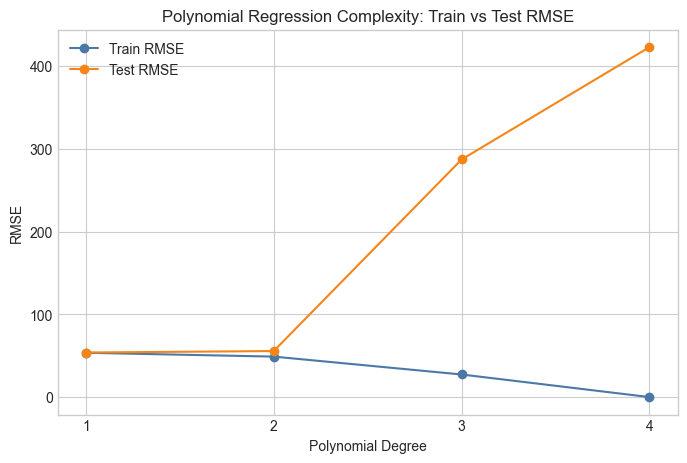

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(polynomial_metrics["degree"], polynomial_metrics["train_rmse"], marker="o", label="Train RMSE", color="#4C78A8")
ax.plot(polynomial_metrics["degree"], polynomial_metrics["test_rmse"], marker="o", label="Test RMSE", color="#F58518")
ax.set_title("Polynomial Regression Complexity: Train vs Test RMSE")
ax.set_xlabel("Polynomial Degree")
ax.set_ylabel("RMSE")
ax.set_xticks(polynomial_metrics["degree"])
ax.legend()
plt.show()

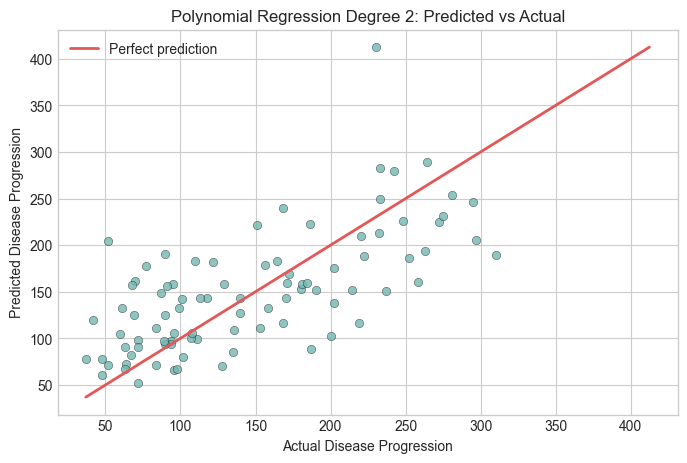

In [14]:
degree_2_model = polynomial_models[2]
degree_2_test_pred = degree_2_model.predict(X_test)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_test, degree_2_test_pred, alpha=0.80, color="#72B7B2", edgecolor="black", linewidth=0.3)
min_value = min(y_test.min(), degree_2_test_pred.min())
max_value = max(y_test.max(), degree_2_test_pred.max())
ax.plot([min_value, max_value], [min_value, max_value], color="#E45756", linewidth=2, label="Perfect prediction")
ax.set_title("Polynomial Regression Degree 2: Predicted vs Actual")
ax.set_xlabel("Actual Disease Progression")
ax.set_ylabel("Predicted Disease Progression")
ax.legend()
plt.show()

### Polynomial Regression Interpretation

Degree 1 is equivalent to the multiple linear model. Degree 2 reduces training error but increases test error, which suggests the model is beginning to fit patterns that do not generalize as well. Degrees 3 and 4 show severe overfitting: training RMSE drops dramatically, but test RMSE becomes much worse and R-squared turns strongly negative.

This train-test gap is the key evidence of overfitting. A model can appear strong on the training set because it memorizes complex interactions, but that does not mean it will perform well on unseen data. The Diabetes dataset has only 442 observations, so high-degree polynomial expansion creates many extra terms relative to the dataset size. This demonstrates that increasing model complexity can harm performance when the added flexibility is not supported by enough data.

## Step 5: Regularization with Ridge and Lasso Regression

Ridge and Lasso Regression are trained across several alpha values. Alpha controls regularization strength: small alpha values behave more like ordinary linear regression, while larger alpha values shrink coefficients more strongly.

In [15]:
alpha_values = [0.001, 0.01, 0.1, 1, 10, 100]
ridge_results = []
lasso_results = []
ridge_models = {}
lasso_models = {}

for alpha in alpha_values:
    ridge_model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=alpha))
    ])
    ridge_model.fit(X_train, y_train)
    ridge_train_pred = ridge_model.predict(X_train)
    ridge_test_pred = ridge_model.predict(X_test)
    ridge_result = evaluate_regression(
        f"Ridge alpha={alpha}",
        y_train,
        ridge_train_pred,
        y_test,
        ridge_test_pred
    )
    ridge_result["alpha"] = alpha
    ridge_results.append(ridge_result)
    ridge_models[alpha] = ridge_model

    lasso_model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=alpha, max_iter=20000))
    ])
    lasso_model.fit(X_train, y_train)
    lasso_train_pred = lasso_model.predict(X_train)
    lasso_test_pred = lasso_model.predict(X_test)
    lasso_result = evaluate_regression(
        f"Lasso alpha={alpha}",
        y_train,
        lasso_train_pred,
        y_test,
        lasso_test_pred
    )
    lasso_result["alpha"] = alpha
    lasso_results.append(lasso_result)
    lasso_models[alpha] = lasso_model

ridge_metrics = pd.DataFrame(ridge_results)
lasso_metrics = pd.DataFrame(lasso_results)

print("Ridge Regression Results")
display(ridge_metrics[["alpha", "train_rmse", "test_mae", "test_mse", "test_rmse", "test_r2"]])

print("Lasso Regression Results")
display(lasso_metrics[["alpha", "train_rmse", "test_mae", "test_mse", "test_rmse", "test_r2"]])

Ridge Regression Results


,alpha,train_rmse,test_mae,test_mse,test_rmse,test_r2
0,0.001,53.558843,42.794102,2900.181731,53.853335,0.452605
1,0.010,53.558846,42.794171,2900.075130,53.852346,0.452625
2,0.100,53.559105,42.796235,2899.054556,53.842869,0.452818
3,1.000,53.575145,42.811999,2892.014566,53.777454,0.454147
4,10.000,53.735609,42.856825,2875.778718,53.626288,0.457211
5,100.000,54.465335,43.250653,2858.224287,53.462363,0.460524


Lasso Regression Results


,alpha,train_rmse,test_mae,test_mse,test_rmse,test_r2
0,0.001,53.558847,42.794066,2900.008373,53.851726,0.452638
1,0.010,53.559240,42.795018,2898.368019,53.836493,0.452947
2,0.100,53.598422,42.805234,2884.624289,53.708698,0.455541
3,1.000,53.862938,42.802984,2824.568094,53.146666,0.466877
4,10.000,57.012312,44.764599,2933.834730,54.164885,0.446253
5,100.000,77.951254,64.006461,5361.533457,73.222493,-0.011963


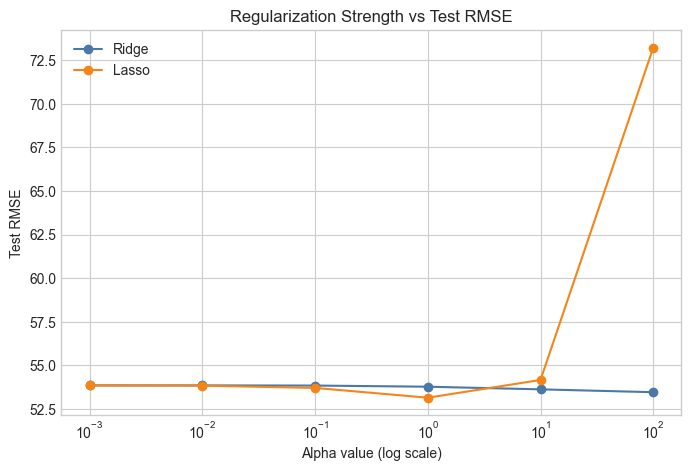

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ridge_metrics["alpha"], ridge_metrics["test_rmse"], marker="o", label="Ridge", color="#4C78A8")
ax.plot(lasso_metrics["alpha"], lasso_metrics["test_rmse"], marker="o", label="Lasso", color="#F58518")
ax.set_xscale("log")
ax.set_title("Regularization Strength vs Test RMSE")
ax.set_xlabel("Alpha value (log scale)")
ax.set_ylabel("Test RMSE")
ax.legend()
plt.show()

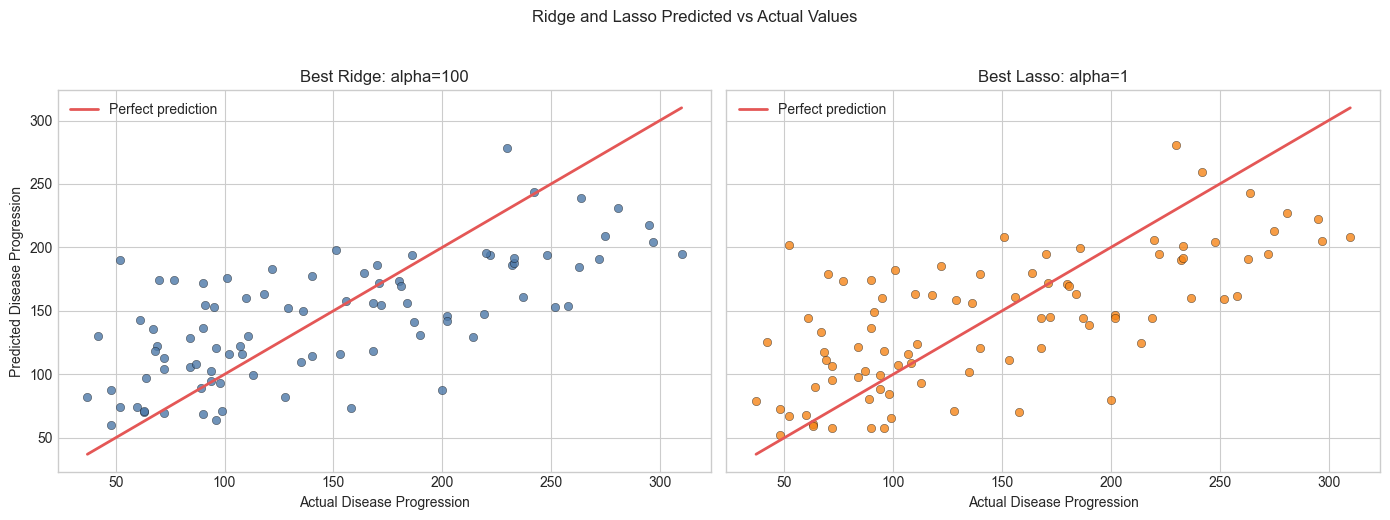

In [17]:
best_ridge = ridge_metrics.loc[ridge_metrics["test_rmse"].idxmin()]
best_lasso = lasso_metrics.loc[lasso_metrics["test_rmse"].idxmin()]

best_ridge_alpha = best_ridge["alpha"]
best_lasso_alpha = best_lasso["alpha"]

best_ridge_pred = ridge_models[best_ridge_alpha].predict(X_test)
best_lasso_pred = lasso_models[best_lasso_alpha].predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

for ax, predictions, title, color in [
    (axes[0], best_ridge_pred, f"Best Ridge: alpha={best_ridge_alpha:g}", "#4C78A8"),
    (axes[1], best_lasso_pred, f"Best Lasso: alpha={best_lasso_alpha:g}", "#F58518"),
]:
    ax.scatter(y_test, predictions, alpha=0.80, color=color, edgecolor="black", linewidth=0.3)
    min_value = min(y_test.min(), predictions.min())
    max_value = max(y_test.max(), predictions.max())
    ax.plot([min_value, max_value], [min_value, max_value], color="#E45756", linewidth=2, label="Perfect prediction")
    ax.set_title(title)
    ax.set_xlabel("Actual Disease Progression")
    ax.legend()

axes[0].set_ylabel("Predicted Disease Progression")
fig.suptitle("Ridge and Lasso Predicted vs Actual Values", y=1.03)
plt.tight_layout()
plt.show()

In [18]:
ridge_coefficients = ridge_models[best_ridge_alpha].named_steps["model"].coef_
lasso_coefficients = lasso_models[best_lasso_alpha].named_steps["model"].coef_

coefficient_comparison = pd.DataFrame({
    "feature": diabetes.feature_names,
    "ridge_coefficient": ridge_coefficients,
    "lasso_coefficient": lasso_coefficients,
})
coefficient_comparison["lasso_zeroed"] = np.isclose(coefficient_comparison["lasso_coefficient"], 0.0)
coefficient_comparison

,feature,ridge_coefficient,lasso_coefficient,lasso_zeroed
0,age,2.093789,0.687032,False
1,sex,-8.168076,-9.297519,False
2,bmi,21.561936,26.219225,False
3,bp,13.926917,15.657314,False
4,s1,-2.898262,-8.228172,False
5,s2,-4.087197,-0.000000,True
6,s3,-9.059339,-9.024087,False
7,s4,6.683867,3.420861,False
8,s5,16.477222,22.636465,False
9,s6,4.688816,2.098647,False


### Regularization Interpretation

Ridge regularization gradually shrinks coefficients as alpha increases, which can reduce variance without removing variables. This is useful when several predictors contribute information and the goal is to stabilize the model rather than remove features. Lasso also shrinks coefficients, but it can push some coefficients to exactly zero, making the model simpler and performing a form of feature selection.

Alpha controls the strength of the penalty. Very small alpha values behave almost like ordinary linear regression. Moderate alpha values can improve test performance by reducing overfitting. Very large alpha values can underfit because the coefficients become too constrained. In this split, Lasso with alpha 1.0 produced the lowest test RMSE among the tested models, while Ridge also slightly improved over ordinary multiple regression.

## Step 6: Model Comparison and Analysis

This section summarizes all model families using the same evaluation metrics.

In [19]:
model_comparison = pd.concat([
    simple_metrics,
    multiple_metrics,
    polynomial_metrics.loc[polynomial_metrics["degree"] == 2, simple_metrics.columns],
    ridge_metrics.loc[[ridge_metrics["test_rmse"].idxmin()], simple_metrics.columns],
    lasso_metrics.loc[[lasso_metrics["test_rmse"].idxmin()], simple_metrics.columns],
], ignore_index=True)

model_comparison

,model,train_rmse,test_mae,test_mse,test_rmse,test_r2
0,Simple Linear Regression (BMI),62.081500,52.259976,4061.825928,63.732456,0.233350
1,Multiple Linear Regression,53.558843,42.794095,2900.193628,53.853446,0.452603
2,Polynomial Regression degree 2,48.919716,43.581693,3096.028307,55.641965,0.415640
3,Ridge alpha=100,54.465335,43.250653,2858.224287,53.462363,0.460524
4,Lasso alpha=1,53.862938,42.802984,2824.568094,53.146666,0.466877


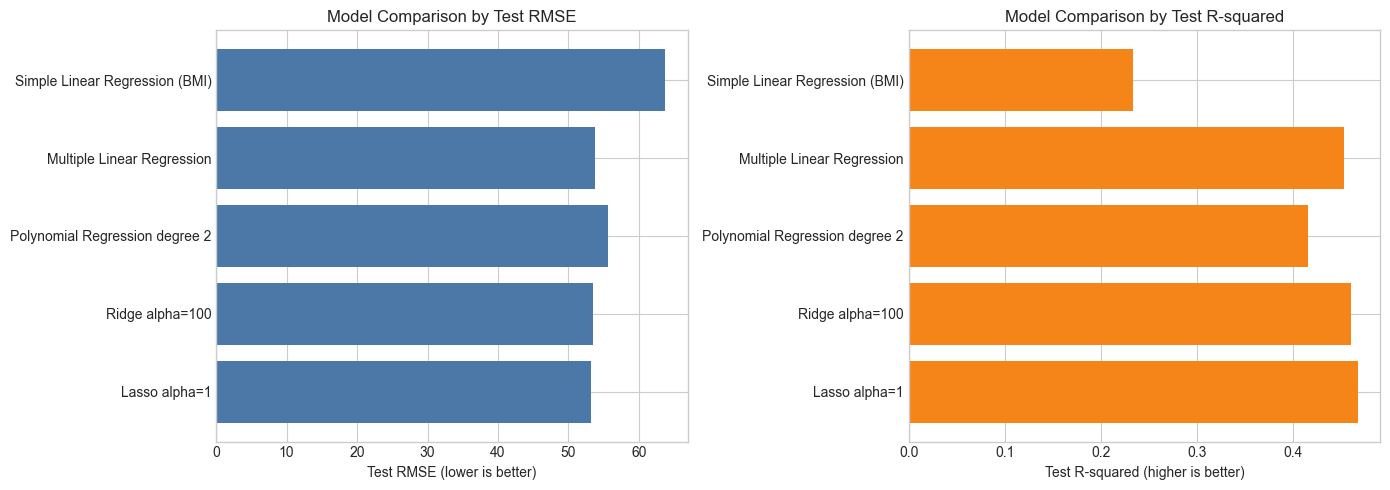

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(model_comparison["model"], model_comparison["test_rmse"], color="#4C78A8")
axes[0].set_title("Model Comparison by Test RMSE")
axes[0].set_xlabel("Test RMSE (lower is better)")
axes[0].invert_yaxis()

axes[1].barh(model_comparison["model"], model_comparison["test_r2"], color="#F58518")
axes[1].set_title("Model Comparison by Test R-squared")
axes[1].set_xlabel("Test R-squared (higher is better)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

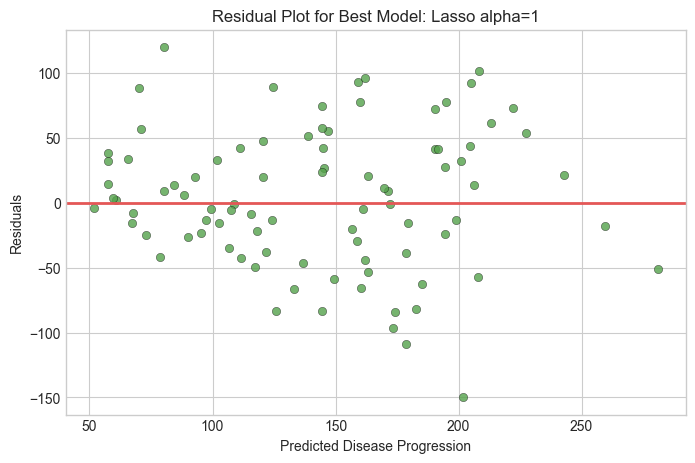

In [21]:
best_model_name = model_comparison.loc[model_comparison["test_rmse"].idxmin(), "model"]
if best_model_name.startswith("Lasso"):
    best_predictions = best_lasso_pred
elif best_model_name.startswith("Ridge"):
    best_predictions = best_ridge_pred
elif best_model_name.startswith("Multiple"):
    best_predictions = multiple_test_pred
elif best_model_name.startswith("Polynomial"):
    best_predictions = degree_2_test_pred
else:
    best_predictions = simple_test_pred

residuals = y_test - best_predictions

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(best_predictions, residuals, alpha=0.80, color="#54A24B", edgecolor="black", linewidth=0.3)
ax.axhline(0, color="#E45756", linewidth=2)
ax.set_title(f"Residual Plot for Best Model: {best_model_name}")
ax.set_xlabel("Predicted Disease Progression")
ax.set_ylabel("Residuals")
plt.show()

### Final Analysis

- Simple Linear Regression using BMI was the weakest model because one feature could not capture enough variation in diabetes progression. It served as a baseline and showed that BMI has useful signal, but not enough by itself.
- Multiple Linear Regression improved performance by using all health measurements. This confirms that disease progression is better explained by a combination of features.
- Polynomial Regression showed why more complexity is not always better. Degree 2 began to overfit, and degrees 3 and 4 overfit severely. The training error became very low, but test performance became much worse.
- Ridge and Lasso helped control model complexity. Ridge improved performance slightly by shrinking coefficients, while Lasso produced the best test RMSE in this train-test split and also simplified the model by shrinking weak predictors more aggressively.
- The residual plot for the best model helps check whether errors are randomly distributed. The residuals are centered around zero, but there is still spread, which means the model captures useful structure but does not explain every pattern in disease progression.
- The Diabetes dataset contains useful linear signal, but prediction remains imperfect. The moderate R-squared values show that disease progression is influenced by patterns not fully captured by these 10 features and these regression models.